In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.figure_factory as ff
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from linearmodels.panel import PanelOLS, RandomEffects
from linearmodels.iv import IV2SLS
from linearmodels.system import IV3SLS
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

In [3]:
df = pd.read_csv(r'C:\Users\rolg0\Downloads\8vo semestre\Econometría I\51_Informacion_estadistica_Credito_Vivienda_Datos_Credito_Asegurado_ok.csv', encoding='latin-1')
df = df.drop_duplicates()
df.head()

,Año,clave_administrador,apoyo_financiamiento,tipo_tasa,tipo_cartera,moneda,plazo_credito,porcentaje_cobertura,frecuencia_pago,numero_creditos,monto_enganche,monto_credito,prima_emitida,prima_cedida,prima_devengada,saldo_principal
0,2015,ABC Capital,Infonavit Apoyo Infonavit,Tasa Fija,Interes Social,UDI,300,25.0,Mensual,5,205481,1302609,8296,0,8296,1207248
1,2015,ABC Capital,Infonavit Apoyo Infonavit,Tasa Fija,Interes Social,UDI,300,30.0,Mensual,4,56747,1078199,8152,0,8152,802724
2,2015,ABC Capital,Infonavit Apoyo Infonavit,Tasa Fija,Media y Residencial,UDI,240,30.0,Mensual,6,214188,3325112,24655,0,24655,2749162
3,2015,ABC Capital,Infonavit Apoyo Infonavit,Tasa Fija,Media y Residencial,UDI,300,15.0,Mensual,1,122820,477180,2148,0,2148,429228
4,2015,ABC Capital,Infonavit Cofinavit,Tasa Fija,Interes Social,UDI,240,10.0,Mensual,2,141455,394419,1260,0,1260,226307


In [3]:
print("Valores nulos por columna:")
print(df.isnull().sum())
df.describe()

Valores nulos por columna:
Año                     0
clave_administrador     0
apoyo_financiamiento    0
tipo_tasa               0
tipo_cartera            0
moneda                  0
plazo_credito           0
porcentaje_cobertura    0
frecuencia_pago         0
numero_creditos         0
monto_enganche          0
monto_credito           0
prima_emitida           0
prima_cedida            0
prima_devengada         0
saldo_principal         0
dtype: int64


,Año,plazo_credito,porcentaje_cobertura,numero_creditos,monto_enganche,monto_credito,prima_emitida,prima_cedida,prima_devengada,saldo_principal
count,76526.000000,76526.000000,76526.000000,76526.000000,7.652600e+04,7.652600e+04,7.652600e+04,7.652600e+04,7.652600e+04,7.652600e+04
mean,2020.024593,237.219729,17.382496,35.022737,6.804281e+06,2.878546e+07,7.087151e+04,7.301310e+03,6.786526e+04,2.283570e+07
std,2.753532,72.706460,8.200845,254.280495,9.053135e+07,3.418722e+08,7.709444e+05,1.193419e+05,7.624229e+05,2.891444e+08
min,2015.000000,12.000000,0.160000,1.000000,0.000000e+00,5.000000e+00,-1.647150e+05,0.000000e+00,-4.701000e+03,0.000000e+00
25%,2018.000000,180.000000,10.000000,1.000000,8.237000e+04,4.409110e+05,5.380000e+02,0.000000e+00,3.890000e+02,3.198270e+05
50%,2020.000000,240.000000,20.000000,1.000000,1.849230e+05,9.016880e+05,1.830500e+03,0.000000e+00,1.553000e+03,6.918725e+05
75%,2022.000000,300.000000,24.097500,5.000000,6.130000e+05,2.858000e+06,7.241750e+03,0.000000e+00,6.345500e+03,2.059793e+06
max,2024.000000,386.000000,85.000000,17404.000000,1.090876e+10,3.275692e+10,6.277473e+07,1.072643e+07,6.277473e+07,2.882843e+10


## Distribución de las variables seleccionadas

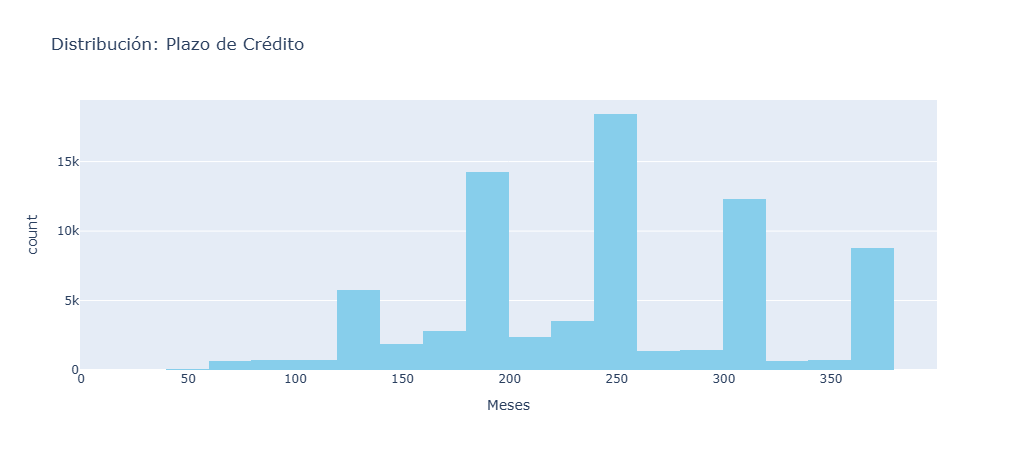

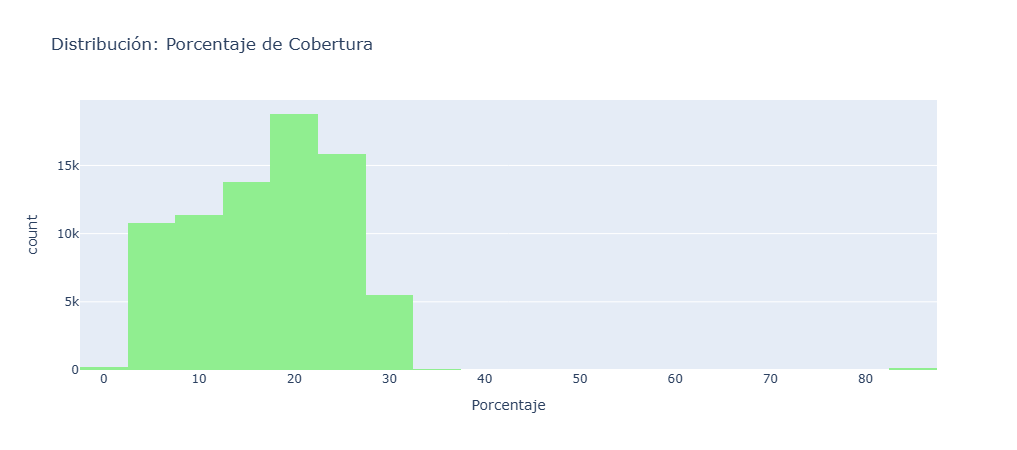

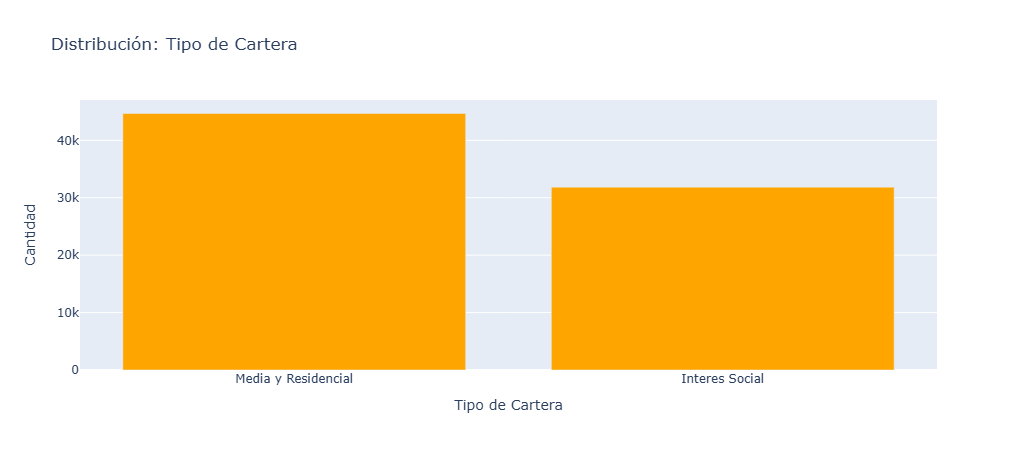

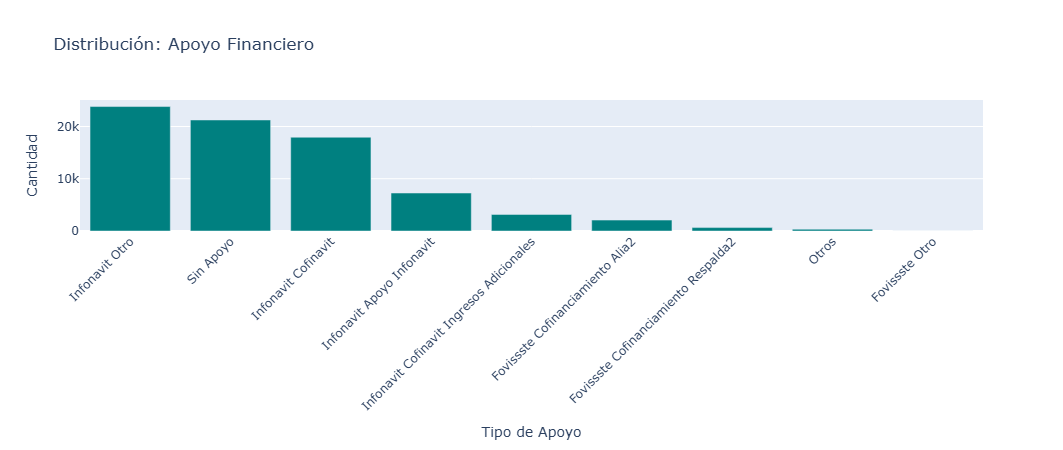

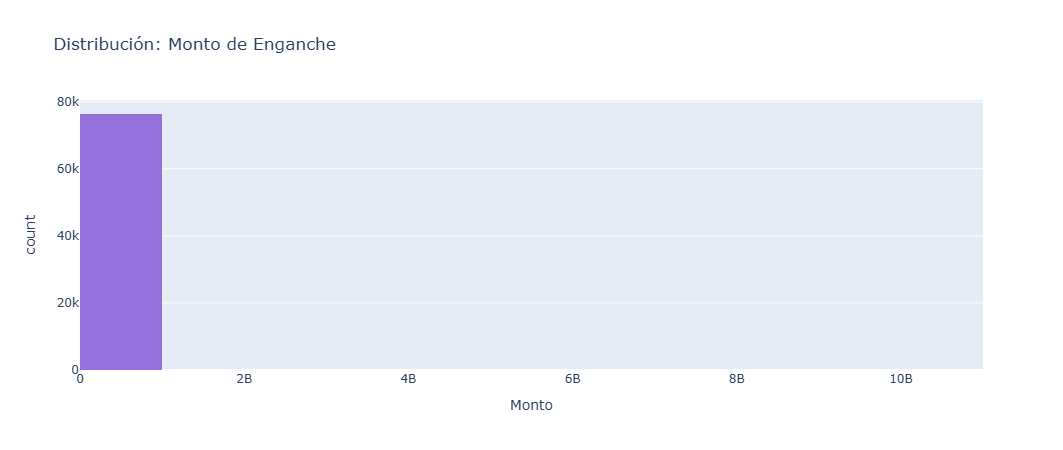

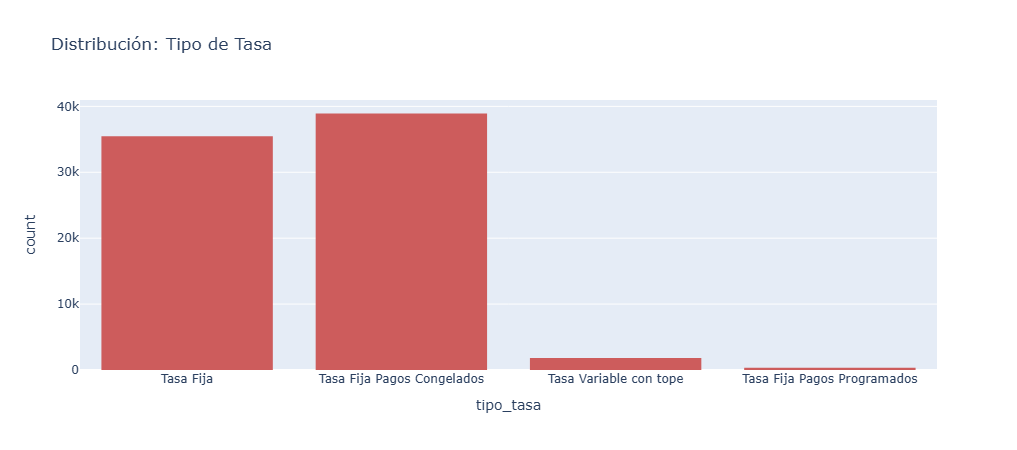

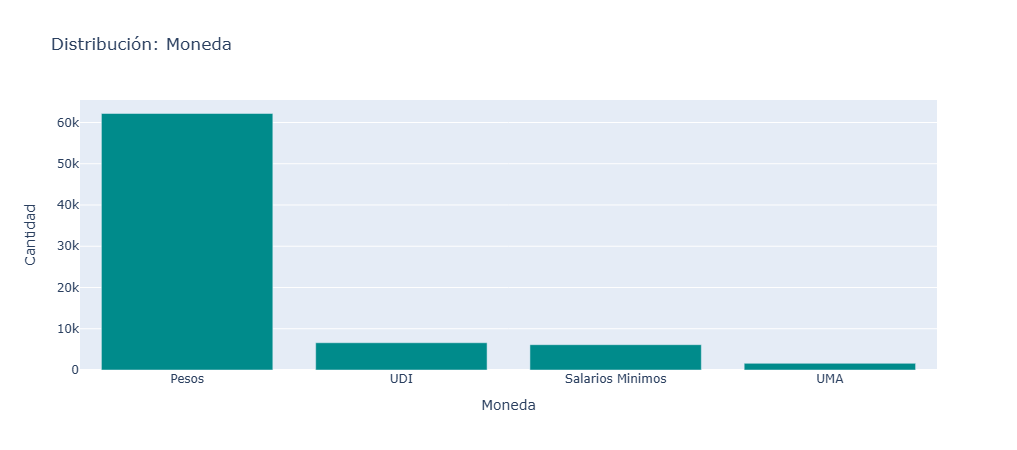

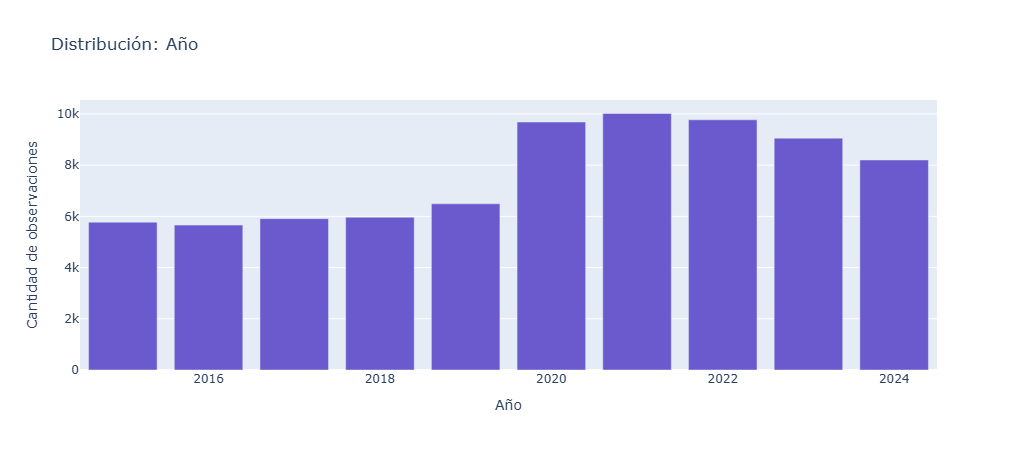

In [4]:
#Plazo de crédito
fig = px.histogram(df, x="plazo_credito", nbins=20, title="Distribución: Plazo de Crédito",
                   labels={"plazo_credito": "Meses"}, color_discrete_sequence=["skyblue"])
fig.update_layout(width=900, height=450)
fig.show()

#Porcentaje de cobertura
fig = px.histogram(df, x="porcentaje_cobertura", nbins=20, title="Distribución: Porcentaje de Cobertura",
                   labels={"porcentaje_cobertura": "Porcentaje"}, color_discrete_sequence=["lightgreen"])
fig.update_layout(width=900, height=450)
fig.show()

#Tipo de Cartera
fig = px.bar(df["tipo_cartera"].value_counts().reset_index(), x="tipo_cartera", y="count",
             title="Distribución: Tipo de Cartera", labels={"tipo_cartera": "Tipo de Cartera", "count": "Cantidad"},
             color_discrete_sequence=["orange"])
fig.update_layout(width=900, height=450)
fig.show()

#Apoyo Financiero
fig = px.bar(df["apoyo_financiamiento"].value_counts().reset_index(), x="apoyo_financiamiento", y="count",
             title="Distribución: Apoyo Financiero",
             labels={"apoyo_financiamiento": "Tipo de Apoyo", "count": "Cantidad"},
             color_discrete_sequence=["teal"])
fig.update_layout(width=900, height=450, xaxis_tickangle=-45)
fig.show()

#Monto de Enganche
fig = px.histogram(df, x="monto_enganche", nbins=20,title="Distribución: Monto de Enganche",labels={"monto_enganche":"Monto"},
                   color_discrete_sequence=["mediumpurple"])
fig.update_layout(width=900, height=450)
fig.show()


#Tasa
fig = px.histogram(df, x="tipo_tasa", nbins=20, title="Distribución: Tipo de Tasa",
                   labels={"tasa_variable":"Tasa"},color_discrete_sequence=["indianred"])
fig.update_layout(width=900, height=450)
fig.show()

#Moneda
fig = px.bar(df["moneda"].value_counts().reset_index(), x="moneda", y="count",title="Distribución: Moneda",
             labels={"moneda":"Moneda","count":"Cantidad"}, color_discrete_sequence=["darkcyan"])
fig.update_layout(width=900, height=450)
fig.show()

#Año
fig = px.bar(df["Año"].value_counts().sort_index().reset_index(),x="Año", y="count", title="Distribución: Año",
             labels={"Año":"Año","count":"Cantidad de observaciones"}, color_discrete_sequence=["slateblue"])
fig.update_layout(width=900, height=450)
fig.show()

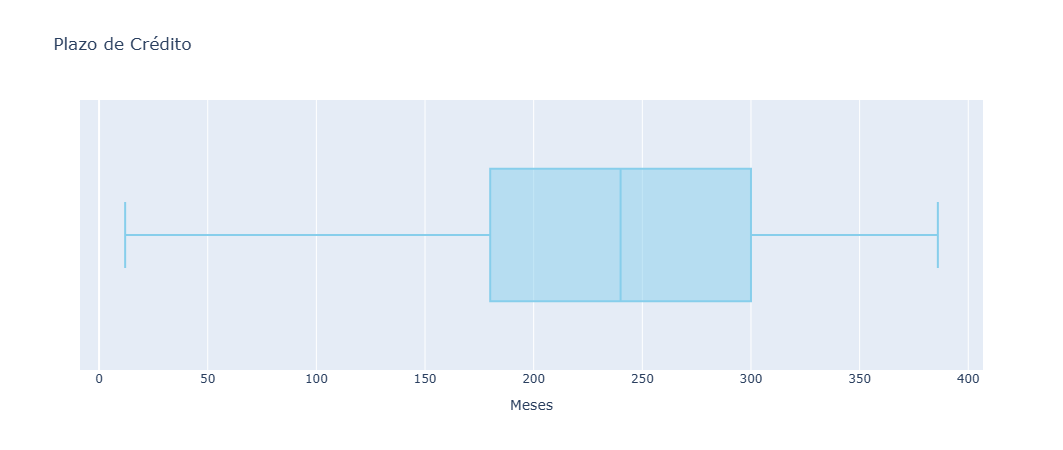

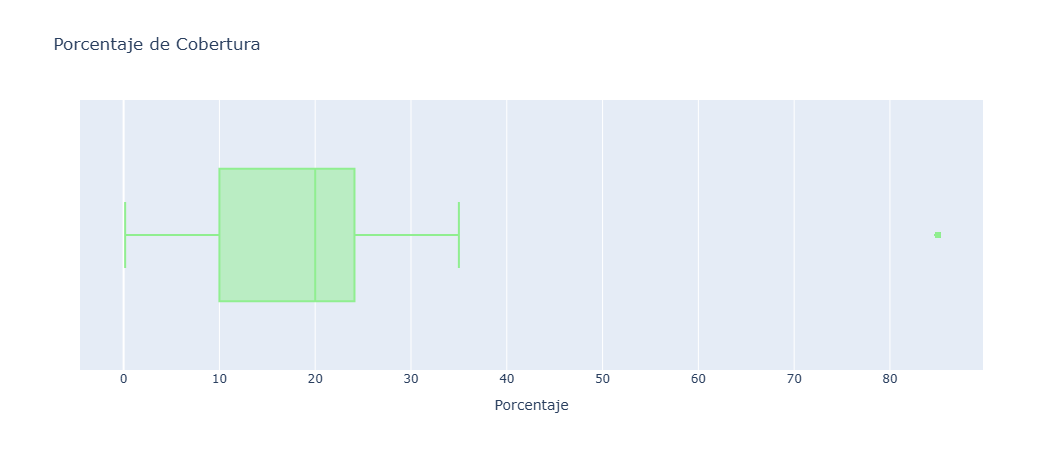

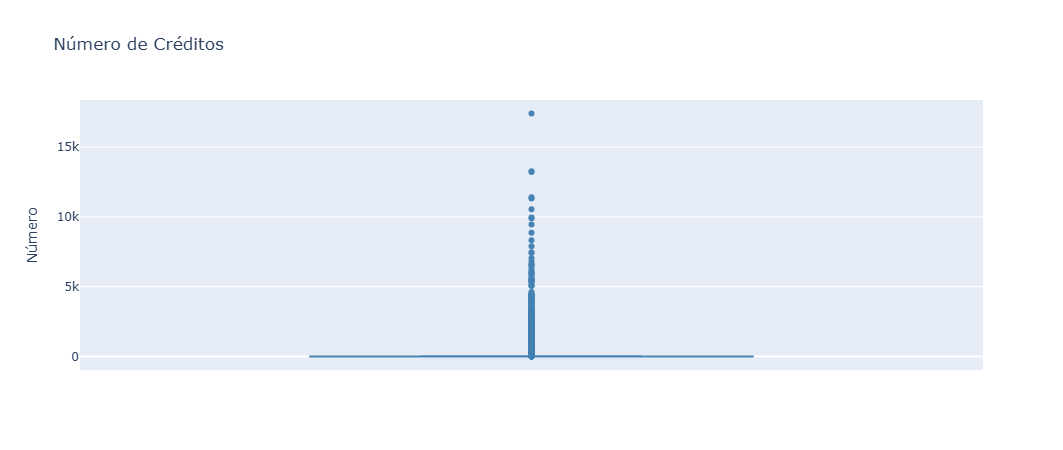

In [5]:
#Boxplot para Plazo de Crédito
fig = px.box(df, x="plazo_credito", title="Plazo de Crédito",
             labels={"plazo_credito": "Meses"}, color_discrete_sequence=["skyblue"])
fig.update_layout(width=900, height=450)
fig.show()

#Boxplot para Porcentaje de Cobertura
fig = px.box(df, x="porcentaje_cobertura", title="Porcentaje de Cobertura",
             labels={"porcentaje_cobertura": "Porcentaje"}, color_discrete_sequence=["lightgreen"])
fig.update_layout(width=900, height=450)
fig.show()

#Boxplot número de créditos
fig = px.box(df, y="numero_creditos", title="Número de Créditos",
             labels={"numero_creditos":"Número"},color_discrete_sequence=["steelblue"])
fig.update_layout(width=900, height=450)
fig.show()

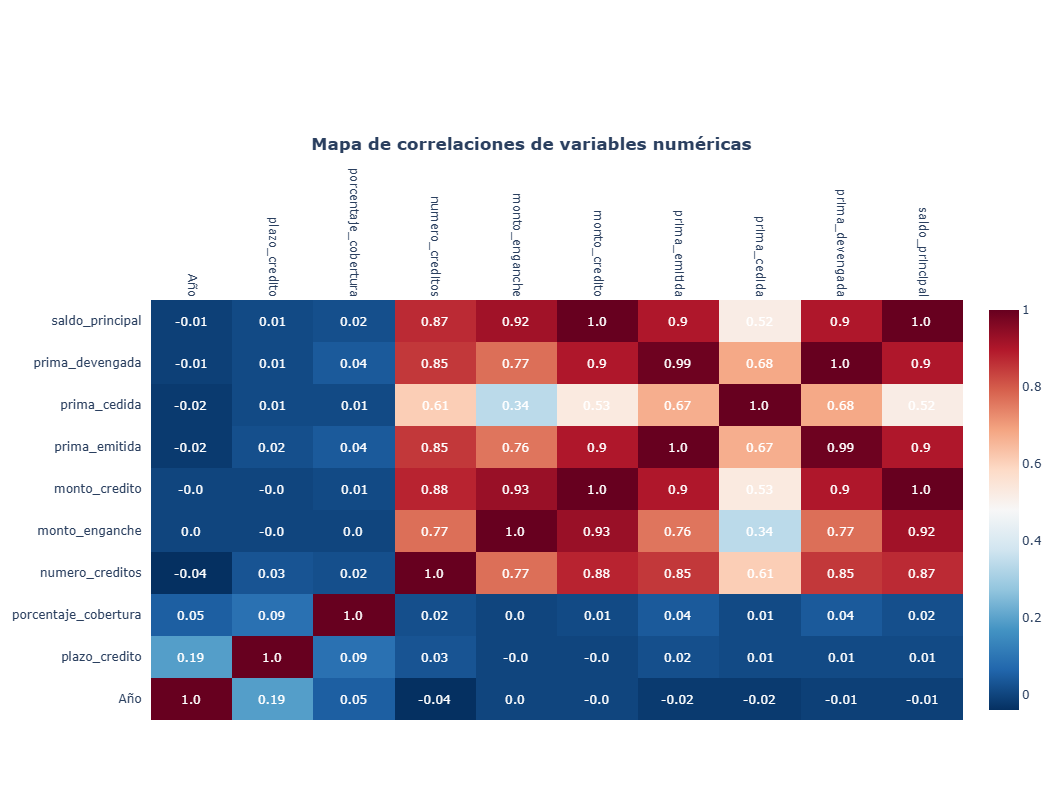

In [6]:
df_num = df.select_dtypes(include="number")
matriz_corr = df_num.corr()

fig = ff.create_annotated_heatmap(z=matriz_corr.values.round(2),x=list(matriz_corr.columns),
    y=list(matriz_corr.index),colorscale="RdBu_r", showscale=True
)

fig.update_layout(title=dict(text="<b>Mapa de correlaciones de variables numéricas</b>",x=0.5),
    width=1000,height=800,margin=dict(t=300, l=120)
)
fig.update_xaxes(tickangle=90)
fig.show()

# Modelo de Regresión Lineal Múltiple por Mínimos Cuadrados

## **Modelo base propuesto**

$$
monto\_credito_i =
\beta_0
+ \beta_1\,plazo\_credito_i
+ \beta_2\,porcentaje\_cobertura_i
+ \beta_3\,monto\_enganche_i
+ \beta_4\,A\tilde{n}o_i
+ \beta_5\,tipo\_apoyo_i
+ \beta_6\,tipo\_cartera_i
+ \varepsilon_i
$$

### Separación de los datos en entrenamiento-prueba

In [7]:
# Separación train y test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=67)

data_model_train = train_df.dropna()
data_model_test = test_df.dropna()

In [8]:
# Variable dependiente
y_train = train_df["monto_credito"]
y_test = test_df["monto_credito"]

# Clasificar apoyo
def clasificar_apoyo(x):
    x = str(x).lower()
    if "infonavit" in x or "fovissste" in x:
        return 1
    else:
        return 0

# Dummy apoyo
train_df["con_apoyo"] = (train_df["apoyo_financiamiento"].apply(clasificar_apoyo))

test_df["con_apoyo"] = (test_df["apoyo_financiamiento"].apply(clasificar_apoyo)) # Sin apoyo = 0, Infonavit/Fovissste = 1

# Dummy cartera
train_df["tipo_cartera"] = (train_df["tipo_cartera"] == "Media y Residencial").astype(int)

test_df["tipo_cartera"] = (test_df["tipo_cartera"] == "Media y Residencial").astype(int)

X_train = train_df[["plazo_credito","porcentaje_cobertura","monto_enganche","Año","con_apoyo","tipo_cartera"]]

# Intercepto
X_train = sm.add_constant(X_train)

# Modelo
modelo_base = sm.OLS(y_train, X_train).fit()
print(modelo_base.summary())

                            OLS Regression Results                            
Dep. Variable:          monto_credito   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                 6.499e+04
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        12:02:08   Log-Likelihood:            -1.2317e+06
No. Observations:               61220   AIC:                         2.463e+06
Df Residuals:                   61213   BIC:                         2.463e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  1.58e+09 

Modelo ajustado

$$
\begin{aligned}
\text{monto\_credito} =\;& 1.619 \times 10^{9} \\
&+ 2.532 \times 10^{4}\,\text{plazo\_credito} \\
&+ 5.804 \times 10^{5}\,\text{porcentaje\_cobertura} \\
&+ 3.487\,\text{monto\_enganche} \\
&- 8.031 \times 10^{5}\,\text{Año} \\
&- 1.589 \times 10^{7}\,\text{con\_apoyo} \\
&+ 6.643 \times 10^{6}\,\text{tipo\_cartera} \\
&+ \varepsilon
\end{aligned}
$$

En el modelo estimado, un incremento de una unidad en el plazo del crédito se asocia con un aumento promedio de aproximadamente 25,320 pesos en el monto del crédito. Asimismo, un incremento de una unidad en el porcentaje de cobertura aumenta el monto del crédito en alrededor de 580,400 pesos. De igual manera, cada peso adicional en el monto del enganche se relaciona con un incremento promedio de aproximadamente 3.49 pesos en el monto del crédito.  

Por otro lado, el coeficiente negativo asociado al año indica que, manteniendo constantes las demás variables, el monto del crédito tiende a disminuir en aproximadamente 803,100 pesos por cada año adicional en el periodo analizado. En cuanto a las variables dicotómicas, el coeficiente de tipo_apoyo sugiere que los créditos que cuentan con apoyo institucional presentan, en promedio, un monto aproximadamente 15,890,000 pesos menor que aquellos sin apoyo, mientras que los créditos pertenecientes a la cartera media y residencial presentan en promedio un monto mayor de aproximadamente 6,643,000 pesos respecto a los créditos de interés social, manteniendo constantes las demás variables del modelo.

In [9]:
X_test = test_df[["plazo_credito", "porcentaje_cobertura", "monto_enganche", "Año", "con_apoyo", "tipo_cartera"]]
X_test = sm.add_constant(X_test)
pred_test = modelo_base.predict(X_test)

resid_test = y_test - pred_test

In [10]:
# VIF 
X_vif = X_train.drop(columns="const")
vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])]
print(vif)

               Variable        VIF
0         plazo_credito  12.732059
1  porcentaje_cobertura   5.530859
2        monto_enganche   1.012857
3                   Año  17.286423
4             con_apoyo   3.890483
5          tipo_cartera   2.431327


In [11]:
# Prueba de Breuch-Pagan para el modelo base

bp_test = het_breuschpagan(resid_test, X_test)

labels = ["LM Statistic", "LM-Test p-value", "F-Statistic", "F-Test p-value"]
print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(5784.344013187198), 'LM-Test p-value': np.float64(0.0), 'F-Statistic': np.float64(1549.007147151597), 'F-Test p-value': np.float64(0.0)}


In [12]:
# Prueba de Ramsey-Reset para el modelo base

reset = linear_reset(modelo_base, power=2, use_f=True)
print(reset)

<F test: F=7184.72466083055, p=0.0, df_denom=6.12e+04, df_num=1>


## **Modelo modificado**  
#### Para tratar de corregir la heterocedasticidad, se establece un modelo Log-Log, se consideran más variables dummies y términos cuadráticos

In [13]:
# Logaritmos de las variables principales

df["log_monto"] = np.log1p(df["monto_credito"])
df["log_enganche"] = np.log1p(df["monto_enganche"])
df["log_plazo"] = np.log1p(df["plazo_credito"])

df["prima_pos"] = df["prima_devengada"].clip(lower=0)
df["prima_neg_dummy"] = (df["prima_devengada"] < 0).astype(int)
df["log_prima_pos"] = np.log1p(df["prima_pos"])

def dummy_apoyo(x):
    x = str(x).lower()
    if "infonavit" in x:
        return "Infonavit"
    if "fovissste" in x:
        return "Fovissste"
    if "sin apoyo" in x:
        return "Sin Apoyo"
    return "Otros"

# Dummy apoyo_financiamiento
df["apoyo_cat"] = df["apoyo_financiamiento"].apply(dummy_apoyo)

df["apoyo_cat"] = pd.Categorical(df["apoyo_cat"], categories=["Sin Apoyo", "Infonavit", "Fovissste", "Otros"])

# Dummy tipo_cartera

df["tipo_cartera_dummy"] = (df["tipo_cartera"] == "Media y Residencial").astype(int)

df["log_enganche_c"] = df["log_enganche"] - df["log_enganche"].mean()

# Término cuadrático de cobertura

df["cobertura_c"] = df["porcentaje_cobertura"] - df["porcentaje_cobertura"].mean()
df["cobertura_c_sq"] = df["cobertura_c"]**2


# Término cuadrático de plazo 

df["log_plazo_sq"] = df["log_plazo"] ** 2

In [14]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42 )
data_model_train = train_df.dropna()

data_model_test = test_df.dropna()

#### **Modelo 2:**

$$
\begin{aligned}
\log(\text{monto}_i) =\;& \beta_0 
+ \beta_1 \log(\text{plazo}_i) 
+ \beta_2 \log(\text{enganche}_i) \\
&+ \beta_3 \text{porcentaje\_cobertura}_i 
+ \beta_4 \text{porcentaje\_cobertura}_i^2 \\
&+ \beta_5 \text{tipo\_cartera\_dummy}_i \\
&+ \sum_{j} \gamma_j \mathbf{1}(\text{tipo\_tasa}_i = j) \\
&+ \sum_{k} \delta_k \mathbf{1}(\text{apoyo\_cat}_i = k) \\
&+ \sum_{t} \theta_t \mathbf{1}(\text{Año}_i = t) \\
&+ \beta_6 \log(\text{prima\_pos}_i) 
+ \beta_7 \text{prima\_neg\_dummy}_i \\
&+ \sum_{m} \lambda_m \mathbf{1}(\text{moneda}_i = m)
+ \varepsilon_i
\end{aligned}
$$

En el modelo se usa $\log(\text{monto})$ porque permite interpretar los efectos en términos porcentuales y además ayuda a estabilizar la varianza, reduciendo problemas de heterocedasticidad. $\log(\text{plazo})$ refleja que un mayor plazo aumenta el monto al ampliar la capacidad de pago, pero no de forma proporcional constante. $\log(\text{enganche})$ capta que un mayor pago inicial reduce el riesgo y permite acceder a montos mayores, también con un efecto proporcional. El porcentaje de cobertura se incluye en nivel y al cuadrado para capturar que al inicio reduce el riesgo y aumenta el monto, pero su efecto se va agotando conforme la cobertura es más alta. La variable de tipo de cartera se incorpora para distinguir diferencias estructurales en el riesgo del crédito que afectan directamente el monto otorgado.

Las variables como tipo de tasa, apoyos, año y moneda se incluyen como dummies para reflejar cómo cambian las condiciones del crédito y del entorno y cómo eso impacta directamente el monto otorgado. El tipo de tasa afecta el monto porque distintas estructuras de pago implican distintos niveles de riesgo y capacidad de financiamiento. Los apoyos modifican el monto al actuar como subsidios o alivios financieros que facilitan créditos más altos. El año captura cambios en el entorno económico y regulatorio que influyen en la oferta y demanda de crédito. La moneda afecta el monto porque introduce diferencias en riesgo cambiario y condiciones financieras. La prima devengada se divide para reflejar correctamente su impacto en el monto, cuando es positiva actúa como un costo adicional, por lo que un aumento en ella reduce el monto del crédito y se modela en log para capturar ese efecto proporcional. Cuando es negativa, implica una pérdida o ajuste adverso en el crédito, lo que también reduce el monto, pero de forma discreta, por eso se usa una dummy que identifica ese caso. Así, el modelo permite que ambos escenarios afecten negativamente al crédito, pero diferenciando si el efecto es gradual o un cambio brusco.

In [15]:
modelo_2 = smf.ols("""
log_monto ~ log_plazo + log_enganche  + porcentaje_cobertura + I(porcentaje_cobertura**2) 
+ tipo_cartera_dummy + C(tipo_tasa) + C(apoyo_cat, Treatment(reference="Sin Apoyo")) + C(Año) + log_prima_pos + prima_neg_dummy  + C(moneda) 
""", data=data_model_train).fit()
print(modelo_2.summary())

                            OLS Regression Results                            
Dep. Variable:              log_monto   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.718
Method:                 Least Squares   F-statistic:                     6221.
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        12:02:11   Log-Likelihood:                -81700.
No. Observations:               61220   AIC:                         1.635e+05
Df Residuals:                   61194   BIC:                         1.637e+05
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

$$
\begin{aligned}
\log(\text{monto}_i) =\;& 9.9225 
+ 0.2294\,\mathbf{1}(\text{Tasa Fija Pagos Congelados})_i \\
&+ 0.2761\,\mathbf{1}(\text{Tasa Fija Pagos Programados})_i 
- 0.5948\,\mathbf{1}(\text{Tasa Variable con tope})_i \\
&- 0.0681\,\mathbf{1}(\text{Infonavit})_i 
+ 0.2909\,\mathbf{1}(\text{Otros})_i 
+ 0.1439\,\mathbf{1}(\text{Sin Apoyo})_i \\
&+ 0.2444\,\mathbf{1}(\text{Año 2016})_i 
+ 0.2516\,\mathbf{1}(\text{Año 2017})_i \\
&- 0.3521\,\mathbf{1}(\text{Año 2018})_i 
- 0.3721\,\mathbf{1}(\text{Año 2019})_i \\
&- 0.4178\,\mathbf{1}(\text{Año 2020})_i 
- 0.5299\,\mathbf{1}(\text{Año 2021})_i \\
&- 0.4984\,\mathbf{1}(\text{Año 2022})_i 
- 0.5048\,\mathbf{1}(\text{Año 2023})_i \\
&+ 0.7026\,\mathbf{1}(\text{Año 2024})_i \\
&- 0.1201\,\mathbf{1}(\text{Salarios Mínimos})_i 
- 0.6190\,\mathbf{1}(\text{UDI})_i 
- 0.3075\,\mathbf{1}(\text{UMA})_i \\
&- 0.0958 \log(\text{plazo}_i) 
+ 0.1535 \log(\text{enganche}_i) \\
&- 0.0399\,\text{porcentaje\_cobertura}_i 
+ 0.0006\,\text{porcentaje\_cobertura}_i^2 \\
&- 1.067\times 10^{-16}\,\text{tipo\_cartera\_dummy}_i \\
&+ 0.4871 \log(\text{prima\_pos}_i) 
+ 2.5213\,\text{prima\_neg\_dummy}_i 
+ \varepsilon_i
\end{aligned}
$$

In [16]:
pred_2 = modelo_2.predict(data_model_test)
resid_2 = (data_model_test["log_monto"]- pred_2)

In [17]:
# Matriz de diseño X
X_2 = modelo_2.model.exog
nombres_2 = modelo_2.model.exog_names
vif = pd.DataFrame()
vif["variable"] = nombres_2
vif["VIF"] = [variance_inflation_factor(X_2, i)
    for i in range(X_2.shape[1])]

vif

,variable,VIF
0,Intercept,311.407154
1,C(tipo_tasa)[T.Tasa Fija Pagos Congelados],1.759816
2,C(tipo_tasa)[T.Tasa Fija Pagos Programados],1.014238
3,C(tipo_tasa)[T.Tasa Variable con tope],1.054436
4,"C(apoyo_cat, Treatment(reference=""Sin Apoyo""))...",1.467544
5,"C(apoyo_cat, Treatment(reference=""Sin Apoyo""))...",1.112950
6,"C(apoyo_cat, Treatment(reference=""Sin Apoyo""))...",1.035115
7,C(Año)[T.2016],1.839190
8,C(Año)[T.2017],1.886927
9,C(Año)[T.2018],1.922457


In [18]:
# Prueba de Breuch-Pagan para el modelo 2
residuos = modelo_2.resid         
X_test_2 = modelo_2.model.exog
bp_test = het_breuschpagan(residuos, X_test_2)

labels = ["LM Stat", "LM p-value", "F Stat", "F p-value"]
dict(zip(labels, bp_test))

{'LM Stat': np.float64(6523.248415248291),
 'LM p-value': np.float64(0.0),
 'F Stat': np.float64(291.9249512682124),
 'F p-value': np.float64(0.0)}

In [19]:
# Prueba de Ramsey-Reset para el modelo 2

reset_test = linear_reset(modelo_2, power=2, use_f=True)
reset_test

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=27772.59572651936, p=0.0, df_denom=6.12e+04, df_num=1>

## Modelo 3 (corrección de errores robustos)

In [20]:
modelo_3 = smf.ols("""
log_monto ~ log_plazo + log_enganche  + porcentaje_cobertura + I(porcentaje_cobertura**2) 
+ tipo_cartera_dummy + C(tipo_tasa) + C(apoyo_cat) + C(Año) + log_prima_pos + prima_neg_dummy  + C(moneda) 
""", data=data_model_train).fit()

modelo_3 = modelo_3.get_robustcov_results(cov_type='HC3')
print(modelo_3.summary())

                            OLS Regression Results                            
Dep. Variable:              log_monto   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.718
Method:                 Least Squares   F-statistic:                     3353.
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        12:02:19   Log-Likelihood:                -81700.
No. Observations:               61220   AIC:                         1.635e+05
Df Residuals:                   61194   BIC:                         1.637e+05
Df Model:                          25                                         
Covariance Type:                  HC3                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

# Construcción del modelo final

A partir del modelo 3 se identifican dos limitaciones, la primera es la heterogeneidad no observada entre segmentos del mercado hipotecario, definidos por la combinación de moneda y tipo de tasa, así como entre años, asi mismo, el OLS no controla estas fuentes de variación de manera adecuada, lo que puede sesgar los coeficientes por variables omitidas estructurales. La segunda es la posible endogeneidad de `log_enganche`, es decir, el enganche y el monto del crédito pueden determinarse de forma simultánea durante la negociación crediticia, lo que también introduciría sesgo en una estimación por MCO.

Para abordar el primer punto, el modelo final adopta un marco de datos panel con efectos individuales por segmento de mercado, eligiendo entre Efectos Fijos y Efectos Aleatorios mediante la prueba de Hausman. Para el segundo, se realiza una prueba de robustez con IV2SLS instrumentando el enganche con una variable exógena.

### Preparación de la estructura de panel

En esta parte se construye la variable categórica `grupo_mercado` como la combinación de moneda y tipo de tasa, de modo que cada nivel identifica un segmento estructuralmente homogéneo del mercado hipotecario. Esta variable actúa como entidad del panel, mientras que `Año` funciona como segundo nivel del MultiIndex. El MultiIndex es solo formato técnico para distinguir las dos dimensiones, esto no implica ningún orden ni dependencia entre periodos.

In [21]:
# Identificador categórico de segmento de mercado (moneda × tipo de tasa)
df["grupo_mercado"] = df.groupby(["moneda", "tipo_tasa"]).ngroup()

# División entrenamiento/prueba
train_df, test_df = train_test_split(df, test_size=0.2, random_state=67)

# Eliminamos nulos en variables que entrarán al modelo
panel_train = train_df.dropna()
panel_test  = test_df.dropna()

# MultiIndex (entidad, periodo) 
panel_train_idx = panel_train.set_index(["grupo_mercado", "Año"])
panel_test_idx  = panel_test.set_index(["grupo_mercado", "Año"])

print(f"Observaciones train : {len(panel_train_idx)}")
print(f"Observaciones test  : {len(panel_test_idx)}")
print(f"Entidades (segmentos de mercado): {panel_train_idx.index.get_level_values(0).nunique()}")
print(f"Periodos (años): {panel_train_idx.index.get_level_values(1).nunique()}")


Observaciones train : 61220
Observaciones test  : 15306
Entidades (segmentos de mercado): 11
Periodos (años): 10


### Modelo de Efectos Fijos

Se estima `PanelOLS` incluyendo efectos fijos de entidad, que absorben la heterogeneidad estructural no observada por segmento de mercado, y efectos fijos de periodo, que actúan como dummies de año equivalentes a `C(Año)` y absorben shocks comunes a todo el sistema. La estimación usa errores estándar robustos a heterocedasticidad.

In [23]:
# Especificación FE con las variables del modelo 3 más términos no lineales e interacción
# Las dummies de moneda, tipo_tasa y año quedan absorbidas por los efectos fijos
fe_formula = ( "log_monto ~ log_plazo + log_plazo_sq + log_enganche + log_plazo:log_enganche "
               "+ porcentaje_cobertura + cobertura_c_sq " "+ tipo_cartera_dummy + log_prima_pos + prima_neg_dummy "
               "+ EntityEffects + TimeEffects")

fe_model = PanelOLS.from_formula(fe_formula, data=panel_train_idx).fit(cov_type="robust")
print(fe_model.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              log_monto   R-squared:                        0.6759
Estimator:                   PanelOLS   R-squared (Between):              0.8785
No. Observations:               61220   R-squared (Within):               0.6132
Date:                Tue, May 19 2026   R-squared (Overall):              0.8629
Time:                        12:02:42   Log-likelihood                -8.169e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                   1.418e+04
Entities:                          11   P-value                           0.0000
Avg Obs:                       5565.5   Distribution:                 F(9,61191)
Min Obs:                       2.0000                                           
Max Obs:                    2.662e+04   F-statistic (robust):             6647.1
                            

### Modelo de Efectos Aleatorios

En esta parte se estima `RE` con las mismas variables explicativas que el modelo de Efectos Fijos, para que la prueba de Hausman sea válida.

In [25]:
# RE con la misma especificación de variables que FE
re_formula = ("log_monto ~ 1 + log_plazo + log_plazo_sq + log_enganche + log_plazo:log_enganche "
              "+ porcentaje_cobertura + cobertura_c_sq "
              "+ tipo_cartera_dummy + log_prima_pos + prima_neg_dummy")

re_model = RandomEffects.from_formula(re_formula, data=panel_train_idx).fit(cov_type="robust")
print(re_model.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:              log_monto   R-squared:                        0.6627
Estimator:              RandomEffects   R-squared (Between):              0.6066
No. Observations:               61220   R-squared (Within):               0.6227
Date:                Tue, May 19 2026   R-squared (Overall):              0.6627
Time:                        12:02:53   Log-likelihood                -8.726e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                   1.336e+04
Entities:                          11   P-value                           0.0000
Avg Obs:                       5565.5   Distribution:                 F(9,61210)
Min Obs:                       2.0000                                           
Max Obs:                    2.662e+04   F-statistic (robust):             5680.0
                            

### Prueba de Hausman

La prueba de Hausman contrasta la hipótesis nula de que los efectos individuales no están correlacionados con los regresores. Bajo esa hipótesis nula, ambos estimadores son consistentes pero el de Efectos Aleatorios es más eficiente, por lo que debe preferirse. Si la hipótesis se rechaza, se aplica Efectos Fijos al modelo.

In [26]:
# Coeficientes comunes a ambos modelos
params_comunes = fe_model.params.index.intersection(re_model.params.index)

# Diferencia de coeficientes y de matrices de varianza
b_diff   = fe_model.params[params_comunes] - re_model.params[params_comunes]
cov_diff = fe_model.cov.loc[params_comunes, params_comunes] - re_model.cov.loc[params_comunes, params_comunes]

# Estadístico de Hausman = (b_FE - b_RE)' [Var(b_FE) - Var(b_RE)]^(-1) (b_FE - b_RE)
hausman_stat = float(b_diff.values @ np.linalg.pinv(cov_diff.values) @ b_diff.values)
gl = len(params_comunes)

if hausman_stat < 0:
    print(f"Estadístico de Hausman: {hausman_stat:.4f} (negativo)")
    print(f"Grados de libertad: {gl}")
    print("Decisión: NO se rechaza H0 (se usa Efectos Aleatorios)")
    usar_re = True
else:
    p_value = 1 - stats.chi2.cdf(hausman_stat, gl)
    print(f"Estadístico de Hausman: {hausman_stat:.4f}")
    print(f"Grados de libertad: {gl}")
    print(f"P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("Decisión: se rechaza H0 (se usa Efectos Fijos)")
        usar_re = False
    else:
        print("Decisión: NO se rechaza H0 (se usa Efectos Aleatorios)")
        usar_re = True

Estadístico de Hausman: 1939.9337
Grados de libertad: 9
P-value: 0.0000
Decisión: se rechaza H0 (se usa Efectos Fijos)


### Modelo final

La prueba de Hausman determina cuál estimador es consistente y eficiente bajo los datos. Si se rechazó la hipótesis nula, el modelo final es de Efectos Fijos; en caso contrario, es de Efectos Aleatorios.  
Al final se dan los coeficientes de regresión con errores estándar robustos a heterocedasticidad y los cuatro $R^2$ del modelo: el $R^2$ *within* mide la variación explicada dentro de cada entidad, el *between* la variación explicada entre entidades, el *overall* la variación total explicada por los regresores, y el $R^2$ *inclusive* incorpora la varianza explicada por los efectos del panel, siendo este último el más comparable al $R^2$ del modelo OLS.

In [27]:
# Modelo final (Efectos Fijos) 
# TimeEffects no tiene estructura temporal que señala la asignación del trabajo final
if usar_re:
    modelo_final = re_model
    tipo_final = "Efectos Aleatorios (RandomEffects)"
else:
    modelo_final = fe_model
    tipo_final = "Efectos Fijos (PanelOLS con EntityEffects + TimeEffects)"

print(f"Modelo final seleccionado por Hausman: {tipo_final}")
print(modelo_final.summary)

# R^2 del modelo final

print("\n" + "="*60)
print("R^2 del modelo final")
print("="*60)
print(f"R^2 within     : {modelo_final.rsquared_within:.4f}  (variación dentro de cada entidad)")
print(f"R^2 between    : {modelo_final.rsquared_between:.4f} (variación entre entidades)")
print(f"R^2 overall    : {modelo_final.rsquared_overall:.4f} (variación total por regresores)")
print(f"R^2 inclusive  : {modelo_final.rsquared_inclusive:.4f} (incluyendo los efectos del panel)")

Modelo final seleccionado por Hausman: Efectos Fijos (PanelOLS con EntityEffects + TimeEffects)
                          PanelOLS Estimation Summary                           
Dep. Variable:              log_monto   R-squared:                        0.6759
Estimator:                   PanelOLS   R-squared (Between):              0.8785
No. Observations:               61220   R-squared (Within):               0.6132
Date:                Tue, May 19 2026   R-squared (Overall):              0.8629
Time:                        12:02:42   Log-likelihood                -8.169e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                   1.418e+04
Entities:                          11   P-value                           0.0000
Avg Obs:                       5565.5   Distribution:                 F(9,61191)
Min Obs:                       2.0000                                           
Max Obs:     

El modelo final presenta un $R^2$ `overall` de 0.86, lo que indica que el conjunto de regresores explica el 86% de la variación total en el monto del crédito, este es el que se tomará de referencia.

### Prueba de robustez con IV2SLS

El enganche y el monto del crédito pueden determinarse simultáneamente en la negociación crediticia, lo que haría que `log_enganche` fuera endógena y sesgara su coeficiente en el modelo final. Para verificar si esa posible endogeneidad afecta sustancialmente los resultados, se estima un IV2SLS instrumentando `log_enganche` con `porcentaje_cobertura`.

Como la librería para IV2SLS no soporta efectos fijos del panel directamente, las dummies de `grupo_mercado` y `Año` se incluyen explícitamente en la fórmula, lo que es equivalente a controlar por entidad y periodo.

In [31]:
# Datos para IV2SLS 
iv_data = panel_train.dropna(subset=["log_monto", "log_plazo", "log_plazo_sq", "log_enganche", "porcentaje_cobertura", 
                                     "tipo_cartera_dummy", "log_prima_pos", "prima_neg_dummy", "grupo_mercado", "Año"])

# log_enganche endógena, instrumentada por porcentaje_cobertura para IV2SLS
# Las dummies de grupo_mercado y Año replican los efectos del panel
modelo_iv = IV2SLS.from_formula( "log_monto ~ 1 + log_plazo + log_plazo_sq + log_plazo:log_enganche "
                                 "+ tipo_cartera_dummy + log_prima_pos + prima_neg_dummy "
                                 "+ C(grupo_mercado) + C(Año) "
                                 "+ [log_enganche ~ porcentaje_cobertura]", data=iv_data).fit(cov_type="robust")
print(modelo_iv.summary)

# Diagnóstico del instrumento 
print("\n" + "="*60)
print("Diagnóstico")
print("="*60)
fs = modelo_iv.first_stage.individual["log_enganche"]
print(f"R^2 : {fs.rsquared:.4f}")
print(f"Estadístico F : {fs.f_statistic.stat:.4f}")
print(f"P-value F                 : {fs.f_statistic.pval:.4f}")

# Comparación del coeficiente correspondiente entre modelo final e IV2SLS
print("\n" + "="*60)
print("Comparación del coeficiente log_enganche")
print("="*60)
coef_final = modelo_final.params["log_enganche"]
coef_iv    = modelo_iv.params["log_enganche"]
print(f"Modelo final ({tipo_final[:2]}): Coef(log_enganche) = {coef_final:.4f}")
print(f"Modelo IV2SLS         : Coef(log_enganche) = {coef_iv:.4f}")
print(f"Diferencia absoluta   : {abs(coef_final - coef_iv):.4f}")

                          IV-2SLS Estimation Summary                          
Dep. Variable:              log_monto   R-squared:                     -2277.1
Estimator:                    IV-2SLS   Adj. R-squared:                -2278.1
No. Observations:               61220   F-statistic:                    16.553
Date:                Tue, May 19 2026   P-value (F-stat)                0.9220
Time:                        12:34:05   Distribution:                 chi2(26)
Cov. Estimator:                robust                                         
                                                                              
                                   Parameter Estimates                                    
                        Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------
Intercept                 -5593.3  2.205e+04    -0.2537     0.7997   -4.88e+04   3.762e+04
log_

En el modelo final, especificamente en el coeficiente de `log_enganche` (0.4922), un aumento de 1% en el enganche se asocia con un aumento aproximado de 0.49% en el monto del crédito. En contraste, el coeficiente estimado por IV2SLS es 471.42 que es imposible en términos económicos, sin contar el sobreajuste señalado por $R^2 = 0.9963$.  
La diferencia entre estos coeficientes señala que no es util usar las variables instrumentales, por lo que el modelo de Efectos Fijos es el más adecuado para usarlo como modelo final. 

### Validación out-of-sample y diagnósticos

Por último se evalúa el desempeño del modelo final en la muestra de prueba mediante el error cuadrático medio en escala logarítmica. Sobre el mismo modelo final se aplican dos pruebas de diagnóstico. La prueba de Breusch-Pagan contrasta la presencia de heterocedasticidad en los residuos, si se rechaza la hipótesis nula, los errores estándar robustos del modelo final ya están corrigiendo el problema en los reportes de significancia. La prueba de Ramsey RESET contrasta si la forma funcional del modelo está bien especificada, introduciendo el cuadrado de los valores ajustados como regresor adicional y verificando si su efecto es significativamente distinto de cero. Ambas pruebas se aplican directamente sobre los residuos y los valores ajustados del modelo final, sin recurrir a modelos auxiliares.

In [30]:
# Predicción y RMSE en la muestra 
pred_final  = modelo_final.predict(data=panel_test_idx).iloc[:, 0]
rmse_test   = np.sqrt(mean_squared_error(panel_test_idx["log_monto"], pred_final))
print(f"RMSE out-of-sample: {rmse_test:.4f}")

# Residuos y valores ajustados del modelo final en entrenamiento
resid_train  = modelo_final.resids
fitted_train = modelo_final.fitted_values.iloc[:, 0]
y_train      = panel_train_idx["log_monto"]

# Matriz de regresores observables 
exog_cols = ["log_plazo", "log_plazo_sq", "log_enganche", "porcentaje_cobertura", "cobertura_c_sq",
             "tipo_cartera_dummy", "log_prima_pos", "prima_neg_dummy"]
X_diag = sm.add_constant(panel_train_idx[exog_cols])

# Alineación
idx_comun = resid_train.index.intersection(X_diag.index)

# Breusch-Pagan sobre los residuos del modelo final 
bp_final = het_breuschpagan(resid_train.loc[idx_comun].values,
                             X_diag.loc[idx_comun].values)
labels_bp = ["LM Statistic", "LM p-value", "F Statistic", "F p-value"]
print("\n[Breusch-Pagan]:", dict(zip(labels_bp, bp_final)))
print("Resultado BP: " + (
    "Se rechaza H0 (existe heterocedasticidad, corregida por errores robustos)"
    if bp_final[1] < 0.05 else
    "No se rechaza H0 (no hay evidencia de heterocedasticidad)"))

# Ramsey RESET sobre los valores ajustados del modelo final 
reset_X = pd.concat([
    X_diag.loc[idx_comun],
    (fitted_train.loc[idx_comun] ** 2).rename("fitted_sq")
], axis=1)
reset_aux = sm.OLS(y_train.loc[idx_comun], reset_X).fit()
reset_p = reset_aux.pvalues["fitted_sq"]
print(f"\n[Ramsey RESET]:")
print(f"  Coeficiente de fitted^2: {reset_aux.params['fitted_sq']:.4f}")
print(f"  t-stat: {reset_aux.tvalues['fitted_sq']:.4f}")
print(f"  p-value: {reset_p:.4f}")
print("Resultado RESET: " + (
    "Se rechaza H0 (existe mala especificación funcional)"
    if reset_p < 0.05 else
    "No se rechaza H0 (el modelo está bien especificado)"))

RMSE out-of-sample: 5.2826

[Breusch-Pagan]: {'LM Statistic': np.float64(3268.681889984831), 'LM p-value': np.float64(0.0), 'F Statistic': np.float64(431.567593484305), 'F p-value': np.float64(0.0)}
Resultado BP: Se rechaza H0 (existe heterocedasticidad, corregida por errores robustos)

[Ramsey RESET]:
  Coeficiente de fitted^2: 0.1751
  t-stat: 244.4355
  p-value: 0.0000
Resultado RESET: Se rechaza H0 (existe mala especificación funcional)


### Conclusión

El modelo final es un modelo panel con Efectos Fijos y errores estándar robustos a heterocedasticidad, estimado por el método de mínimos cuadrados generalizados. La elección entre Efectos Fijos y Efectos Aleatorios se hizo con la prueba de Hausman, que indicó que los efectos individuales están correlacionados con los regresores y, por tanto, que Efectos Fijos es el estimador consistente y eficiente para los datos disponibles.

La estructura funcional incorpora las variables relevantes del modelo 3 enriquecidas con un término cuadrático en el plazo, una interacción entre plazo y enganche, y la cobertura centrada al cuadrado. Esto permite capturar tanto los efectos no lineales del plazo sobre el monto como la posibilidad de que el efecto marginal del plazo dependa del tamaño del enganche, sin perder la interpretabilidad de los coeficientes logarítmicos como elasticidades. La posible endogeneidad de `log_enganche` por simultaneidad con el monto se verificó mediante un IV2SLS instrumentado con `porcentaje_cobertura`.

La prueba de de Breusch-Pagan forma parte de la familia de pruebas asintóticas $\chi^2 (k)$, que como señala Wooldridge (2010, S.3.5.2, pp. 43–45), los tests asintóticos basados en distribuciones chi-cuadrado tienen poder estadístico que tiende a la unidad conforme el tamaño muestral crece, lo que implica que en muestras suficientemente grandes (en este caso `n= 61220`) detectan desviaciones arbitrariamente pequeñas respecto a la hipótesis nula, sin que ello refleje una violación económicamente relevante. La heterocedasticidad detectada por Breusch-Pagan queda corregida en los errores estándar reportados mediante el uso de `cov_type="robust"`, lo que garantiza que las pruebas de significancia sean válidas.

Por otra parte, como igualmente señala Wooldridge (2010, S.6.2.3, pp. 124-125), La prueba de Ramsey RESET es sensible en muestras grandes y puede detectar no linealidades pequeñas sin relevancia económica. Además, el modelo ya incorpora términos cuadráticos e interacciones relevantes, por lo que el rechazo residual probablemente refleja desviaciones de orden superior que no comprometen la interpretación económica ni la consistencia general del modelo.
